Code Explanation:
https://chatgpt.com/c/68dc0f71-5e18-8331-adb5-d5aa943a9bc5

In [2]:
# https://deeplearningcourses.com/c/data-science-natural-language-processing-in-python
# https://www.udemy.com/data-science-natural-language-processing-in-python

# Author: http://lazyprogrammer.me

import numpy as np
import matplotlib.pyplot as plt

import string
import random
# regular expression to search, match and maipulate strings
import re
# A popular HTTP library for sending requests to web servers (GET, POST, etc.) and handling responses. Commonly used for APIs, web scraping,
# or fetching data from the internet.
import requests
# Provides functions for interacting with the operating system: working with files and directories
import os
# Useful for formatting text to a specific width
import textwrap

In [4]:
### create substitution cipher

# one will act as the key, other as the value
# create 26 letters in alphabetical order then cast it to list
letters1 = list(string.ascii_lowercase)
letters2 = list(string.ascii_lowercase)

true_mapping = {}

# shuffle second set of letters
random.shuffle(letters2)

# populate map
# zip will pair elements of 2 lists (letters1 and letters2): creats a tuple
for k, v in zip(letters1, letters2):
  true_mapping[k] = v

M: a 26×26 matrix (since English alphabet has 26 letters).
Each cell M[i, j] represents the count of how many times letter j follows letter i.

It’s initialized with ones (np.ones) for Laplace smoothing (avoiding zeros in probabilities).

pi: a vector of length 26. Each entry pi[i] counts how often a word starts with letter i.

get_word_prob():
Starts with the log-probability of the first character (from pi).

Then loops over the rest of the characters, adding the log-probability of each transition (i→j).

Using np.log is important to:

Prevent underflow (probabilities get tiny when multiplied).

Turn multiplication into addition.

So, get_word_prob("cat") ≈ log P(c) + log P(a|c) + log P(t|a).

get_sequence_prob(): Accepts either:

A string "hello world" → splits into ["hello","world"].

Or a pre-split list ["hello","world"].

Adds up the log-probabilities of all words in the sequence.

So get_sequence_prob("the cat sat") = log P("the") + log P("cat") + log P("sat").

In [5]:
### the language model

# initialize Markov transition matrix
M = np.ones((26, 26))

# initial state distribution
pi = np.zeros(26)

# a function to update the Markov matrix
# Updates the transition matrix when ch1 is followed by ch2.
# Example: "he" → update_transition('h','e') increases the count for 'h'→'e'.
def update_transition(ch1, ch2):
  # ord('a') = 97, ord('b') = 98, ...
  i = ord(ch1) - 97
  j = ord(ch2) - 97
  M[i,j] += 1

# a function to update the initial state distribution
# Updates the initial letter distribution when a word starts with letter ch
def update_pi(ch):
  i = ord(ch) - 97
  pi[i] += 1

# get the log-probability of a word / token
def get_word_prob(word):
  # print("word:", word)
  i = ord(word[0]) - 97
  # start with probability of first character
  logp = np.log(pi[i])

  for ch in word[1:]:
    j = ord(ch) - 97
    logp += np.log(M[i, j]) # update prob
    i = j # update j

  return logp

# get the probability of a sequence of words
def get_sequence_prob(words):
  # if input is a string, split into an array of tokens
  if type(words) == str:
    words = words.split()

  logp = 0
  for word in words:
    logp += get_word_prob(word)
  return logp

In [6]:
### create a markov model based on an English dataset
# is an edit of https://www.gutenberg.org/ebooks/2701
# (I removed the front and back matter)

# download the file
if not os.path.exists('moby_dick.txt'):
  print("Downloading moby dick...")
  r = requests.get('https://lazyprogrammer.me/course_files/moby_dick.txt')
  with open('moby_dick.txt', 'w') as f:
    f.write(r.content.decode())

regex = re.compile('[^a-zA-Z]') means: match any character that is NOT an uppercase or lowercase letter.

^ inside the square brackets [] means negation.

So the set is [^a-zA-Z] = "anything that is not a through z or A through Z".

non_alpha characters are: Spaces, Digits (0–9), Punctuation (.,!?;:"'()[]{}-),

Symbols (@#$%^&*+=_), Special characters (©, …, —, etc.)

Basically everything except letters.

In [8]:
# for replacing non-alpha characters
regex = re.compile('[^a-zA-Z]')

# load in words
for line in open('moby_dick.txt'):
  line = line.rstrip()

  # there are blank lines in the file
  if line:
    line = regex.sub(' ', line) # replace all non-alpha characters with space

    # split the tokens in the line and lowercase
    tokens = line.lower().split()

    for token in tokens:
      # update the model

      # first letter
      ch0 = token[0]
      update_pi(ch0)

      # other letters
      for ch1 in token[1:]:
        update_transition(ch0, ch1)
        ch0 = ch1

# normalize the probabilities
pi /= pi.sum()
M /= M.sum(axis=1, keepdims=True)

In [9]:
### encode a message

# this is a random excerpt from Project Gutenberg's
# The Adventures of Sherlock Holmes, by Arthur Conan Doyle
# https://www.gutenberg.org/ebooks/1661

original_message = '''I then lounged down the street and found,
as I expected, that there was a mews in a lane which runs down
by one wall of the garden. I lent the ostlers a hand in rubbing
down their horses, and received in exchange twopence, a glass of
half-and-half, two fills of shag tobacco, and as much information
as I could desire about Miss Adler, to say nothing of half a dozen
other people in the neighbourhood in whom I was not in the least
interested, but whose biographies I was compelled to listen to.
'''

# Away they went, and I was just wondering whether I should not do well
# to follow them when up the lane came a neat little landau, the coachman
# with his coat only half-buttoned, and his tie under his ear, while all
# the tags of his harness were sticking out of the buckles. It hadn't
# pulled up before she shot out of the hall door and into it. I only
# caught a glimpse of her at the moment, but she was a lovely woman, with
# a face that a man might die for.

# My cabby drove fast. I don't think I ever drove faster, but the others
# were there before us. The cab and the landau with their steaming horses
# were in front of the door when I arrived. I paid the man and hurried
# into the church. There was not a soul there save the two whom I had
# followed and a surpliced clergyman, who seemed to be expostulating with
# them. They were all three standing in a knot in front of the altar. I
# lounged up the side aisle like any other idler who has dropped into a
# church. Suddenly, to my surprise, the three at the altar faced round to
# me, and Godfrey Norton came running as hard as he could towards me.

join: This is a string method that joins elements of a list (or any iterable) into a single string.

''.join(['h','e','l','l','o'])
→ "hello"   (separator is empty string '')

' '.join(['hello','world'])
→ "hello world"   (separator is a space)

'-'.join(['2025','09','30'])
→ "2025-09-30"   (separator is a dash '-')


In [17]:
# a function to encode a message
def encode_message(msg):
  # downcase
  msg = msg.lower()

  # replace non-alpha characters with space
  msg = regex.sub(' ', msg)

  # make the encoded message
  coded_msg = [] # Creates an empty list to store the encoded characters.
  for ch in msg:
    coded_ch = ch # could just be a space
    if ch in true_mapping:
      coded_ch = true_mapping[ch]
    coded_msg.append(coded_ch)

  return ''.join(coded_msg)


encoded_message = encode_message(original_message)


# a function to decode a message
def decode_message(msg, word_map):
  decoded_msg = []
  for ch in msg:
    decoded_ch = ch # could just be a space
    if ch in word_map:
      decoded_ch = word_map[ch]
    decoded_msg.append(decoded_ch)

  return ''.join(decoded_msg)

In [22]:
### run an evolutionary algorithm (genetic) to decode the message
# to create 20 random dna strings of size 26
# this is our initialization point
dna_pool = []
for _ in range(20):
  dna = list(string.ascii_lowercase)
  random.shuffle(dna)
  dna_pool.append(dna)

In [19]:
def evolve_offspring(dna_pool, n_children):
  # make n_children per offspring
  offspring = []

  for dna in dna_pool:
    for _ in range(n_children):
      copy = dna.copy()
      # create 2 random numbers between 0, 25
      j = np.random.randint(len(copy))
      k = np.random.randint(len(copy))

      # switch or swap process
      tmp = copy[j]
      copy[j] = copy[k]
      copy[k] = tmp
      offspring.append(copy)

  return offspring + dna_pool

In [20]:
num_iters = 1000 # number of iterations (generations of offspring)
scores = np.zeros(num_iters)
best_dna = None
best_map = None
best_score = float('-inf') # minimum possible score
for i in range(num_iters):
  if i > 0:
    # get offspring from the current dna pool
    dna_pool = evolve_offspring(dna_pool, 3)

  # calculate score for each dna
  dna2score = {}
  for dna in dna_pool:
    # populate map
    current_map = {}
    for k, v in zip(letters1, dna):
      current_map[k] = v

    decoded_message = decode_message(encoded_message, current_map)
    score = get_sequence_prob(decoded_message)

    # store it
    # needs to be a string to be a dict key
    dna2score[''.join(dna)] = score

    # record the best so far
    if score > best_score:
      best_dna = dna
      best_map = current_map
      best_score = score

  # average score for this generation
  scores[i] = np.mean(list(dna2score.values()))

  # keep the best 5 dna
  # also turn them back into list of single chars
  sorted_dna = sorted(dna2score.items(), key=lambda x: x[1], reverse=True)
  dna_pool = [list(k) for k, v in sorted_dna[:5]]

  if i % 200 == 0:
    print("iter:", i, "score:", scores[i], "best so far:", best_score)

iter: 0 score: -2738.249771443586 best so far: -1962.3654903562665
iter: 200 score: -1150.652548292746 best so far: -950.6277827476433
iter: 400 score: -1047.1386263684653 best so far: -929.5136856065989
iter: 600 score: -1064.2512347418458 best so far: -929.5136856065989
iter: 800 score: -1099.263342307847 best so far: -929.5136856065989


sorted_dna = sorted(dna2score.items(), key=lambda x: x[1], reverse=True)

dna2score.items() = list of (dna_string, score) pairs.

key=lambda x: x[1] → sort by the score (the second element).

reverse=True → highest scores first (best DNAs at the top).

dna_pool = [list(k) for k, v in sorted_dna[:5]]

Takes the best 5 DNAs.

Each k is a string like "asdfgh...".

list(k) turns it back into a list of characters:
"asdf..." → ['a','s','d','f',...].

dna_pool is updated to only hold these top candidates, ready for the next iteration of evolution.

In [25]:
# use best score
decoded_message = decode_message(encoded_message, best_map)

# the best map is reverse mapping (decoding)
print("Log of Likelihood of decoded message:", get_sequence_prob(decoded_message))
print("Log of Likelihood of true message:", get_sequence_prob(regex.sub(' ', original_message.lower())))


# which letters are wrong?
for true, v in true_mapping.items():
  pred = best_map[v]
  if true != pred:
    print("true: %s, pred: %s" % (true, pred))

Log of Likelihood of decoded message: -929.5136856065989
Log of Likelihood of true message: -932.9508705551947
true: j, pred: z
true: k, pred: j
true: z, pred: k


In [26]:
# print the final decoded message
print("Decoded message:\n", textwrap.fill(decoded_message))

print("\nTrue message:\n", original_message)

Decoded message:
 i then lounged down the street and found  as i expected  that there
was a mews in a lane which runs down by one wall of the garden  i lent
the ostlers a hand in rubbing down their horses  and received in
exchange twopence  a glass of half and half  two fills of shag tobacco
and as much information as i could desire about miss adler  to say
nothing of half a doken other people in the neighbourhood in whom i
was not in the least interested  but whose biographies i was compelled
to listen to

True message:
 I then lounged down the street and found,
as I expected, that there was a mews in a lane which runs down
by one wall of the garden. I lent the ostlers a hand in rubbing
down their horses, and received in exchange twopence, a glass of
half-and-half, two fills of shag tobacco, and as much information
as I could desire about Miss Adler, to say nothing of half a dozen
other people in the neighbourhood in whom I was not in the least
interested, but whose biographies I was 

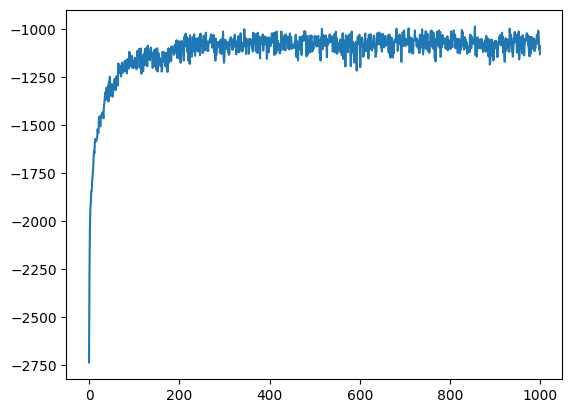

In [27]:
plt.plot(scores)
plt.show()